# 🎯 LỚP 2: DỰ ĐOÁN KHÁCH HÀNG SẼ QUAY LẠI (Repeat Purchase Prediction)

**Câu chuyện kinh doanh:**
Nhận diện ngay từ lần mua đầu tiên liệu khách có quay lại mua tiếp không.
Đây là bài toán kinh điển nhất trong E-commerce: **Repeat Purchase Prediction**.

**Anti Data Leakage (Triệt để):**
- X = Thông tin từ ĐƠN HÀNG ĐẦU TIÊN + PHIÊN ĐẦU TIÊN + Demographics
- Y = Khách hàng có mua ĐƠN THỨ 2 trở lên không? (0/1)
- → X và Y hoàn toàn độc lập về mặt thời gian và định nghĩa

---

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score, precision_score,
    recall_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

from database import query_db
print("✅ Đã tải xong thư viện.")

✅ Đã tải xong thư viện.


## 1. Truy vấn dữ liệu huấn luyện từ Database
**3 nguồn dữ liệu kết hợp:**
- `order_items` → Đơn hàng đầu tiên (giá trị, số lượng item, danh mục)
- `events` → Phiên truy cập đầu tiên (độ sâu, hành vi)
- `users` → Nhân khẩu học (tuổi, giới tính, quốc gia)

In [13]:
query_classification = """
WITH all_orders AS (
    SELECT user_id, order_id,
           ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at) AS order_rank
    FROM order_items
    WHERE status != 'Cancelled'
    GROUP BY user_id, order_id, created_at
),
-- Target Y: Khách hàng có mua đơn THỨ 2 trở lên không?
-- → first_order_value hoàn toàn độc lập với Y
-- → Model học pattern hành vi thực sự, không phải phép cộng
user_labels AS (
    SELECT user_id,
           MAX(CASE WHEN order_rank >= 2 THEN 1 ELSE 0 END) AS is_repeat_buyer
    FROM all_orders
    GROUP BY user_id
),
-- === ĐƠN HÀNG ĐẦU TIÊN ===
first_order AS (
    SELECT user_id, order_id, created_at,
           ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY created_at) AS rn
    FROM order_items
    WHERE status != 'Cancelled'
),
first_order_features AS (
    SELECT
        fo.user_id,
        SUM(oi.sale_price)              AS first_order_value,
        COUNT(*)                        AS first_order_num_items,
        COUNT(DISTINCT p.category)      AS first_order_num_categories
    FROM first_order fo
    JOIN order_items oi ON fo.order_id = oi.order_id AND fo.user_id = oi.user_id
    JOIN products p ON oi.product_id = p.id
    WHERE fo.rn = 1
    GROUP BY fo.user_id
),
-- === PHIÊN TRUY CẬP ĐẦU TIÊN ===
session_start AS (
    SELECT user_id, session_id, MIN(created_at) AS start_time
    FROM events
    WHERE user_id IS NOT NULL
    GROUP BY user_id, session_id
),
ranked_sessions AS (
    SELECT user_id, session_id,
           ROW_NUMBER() OVER(PARTITION BY user_id ORDER BY start_time) AS rn
    FROM session_start
),
first_session_features AS (
    SELECT
        e.user_id,
        MAX(e.sequence_number) AS first_session_depth,
        COUNT(CASE WHEN e.event_type = 'product' THEN 1 END) AS first_session_products_viewed,
        MAX(CASE WHEN e.event_type = 'cart' THEN 1 ELSE 0 END) AS first_session_carted,
        MAX(CASE WHEN e.event_type = 'purchase' THEN 1 ELSE 0 END) AS first_session_purchased,
        MIN(e.traffic_source) AS first_traffic_source
    FROM events e
    JOIN ranked_sessions rs ON e.user_id = rs.user_id AND e.session_id = rs.session_id AND rs.rn = 1
    GROUP BY e.user_id
)
-- === KẾT HỢP TẤT CẢ ===
SELECT
    fof.user_id,
    fof.first_order_value,
    fof.first_order_num_items,
    fof.first_order_num_categories,
    fsf.first_session_depth,
    fsf.first_session_products_viewed,
    fsf.first_session_carted,
    fsf.first_session_purchased,
    fsf.first_traffic_source,
    u.age, u.gender, u.country,
    l.is_repeat_buyer
FROM first_order_features fof
JOIN first_session_features fsf ON fof.user_id = fsf.user_id
JOIN users u ON fof.user_id = u.id
JOIN user_labels l ON fof.user_id = l.user_id
"""

print("⏳ Đang truy vấn dữ liệu từ Database...")
df = query_db(query_classification)

if df is not None:
    print(f"✅ Đã tải {len(df):,} khách hàng.")
    counts = df['is_repeat_buyer'].value_counts()
    print(f"   Y=0 (Mua 1 lần): {counts.get(0, 0):,} | Y=1 (Quay lại): {counts.get(1, 0):,}")

⏳ Đang truy vấn dữ liệu từ Database...
✅ Đã tải 57,422 khách hàng.
   Y=0 (Mua 1 lần): 26,816 | Y=1 (Quay lại): 30,606


## 2. Feature Engineering & Encoding

In [14]:
if df is not None:
    df['age'] = df['age'].fillna(df['age'].median())
    df['gender'] = df['gender'].fillna('Unknown')
    df['country'] = df['country'].fillna('Unknown')

    le_dict = {}
    for col in ['first_traffic_source', 'gender', 'country']:
        le = LabelEncoder()
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

    FEATURE_COLS = [
        # === Đơn hàng đầu tiên (Tín hiệu mạnh nhất) ===
        'first_order_value',            # Giá trị đơn đầu
        'first_order_num_items',        # Số sản phẩm trong đơn đầu
        'first_order_num_categories',   # Số danh mục trong đơn đầu
        # === Phiên truy cập đầu tiên ===
        'first_session_depth',          # Chiều sâu phiên
        'first_session_products_viewed', # Số sản phẩm đã xem
        'first_session_carted',         # Có bỏ giỏ?
        'first_session_purchased',      # Có mua ngay?
        # === Nhân khẩu học ===
        'age',
        'gender_enc',
        'country_enc',
        # === Ngữ cảnh ===
        'first_traffic_source_enc',
    ]

    X = df[FEATURE_COLS]
    y = df['is_repeat_buyer']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"\n✅ Train: {len(X_train):,} | Test: {len(X_test):,}")
    print(f"   Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")


✅ Train: 45,937 | Test: 11,485
   Features (11): ['first_order_value', 'first_order_num_items', 'first_order_num_categories', 'first_session_depth', 'first_session_products_viewed', 'first_session_carted', 'first_session_purchased', 'age', 'gender_enc', 'country_enc', 'first_traffic_source_enc']


## 3. Huấn luyện 3 Mô hình

In [15]:
if df is not None:
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    scale_ratio = neg / pos

    models = {
        'Decision Tree': DecisionTreeClassifier(
            max_depth=6, class_weight='balanced', random_state=42
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=10, class_weight='balanced',
            random_state=42, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            scale_pos_weight=scale_ratio, random_state=42,
            eval_metric='logloss', use_label_encoder=False
        )
    }

    results = {}
    for name, model in models.items():
        print(f"⏳ Đang đào tạo {name}...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        results[name] = {
            'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
            'fpr': fpr, 'tpr': tpr, 'auc': roc_auc
        }
        print(f"  ✅ AUC = {roc_auc:.4f}")

⏳ Đang đào tạo Decision Tree...
  ✅ AUC = 0.7825
⏳ Đang đào tạo Random Forest...
  ✅ AUC = 0.7803
⏳ Đang đào tạo XGBoost...
  ✅ AUC = 0.7821


## 4. Confusion Matrix

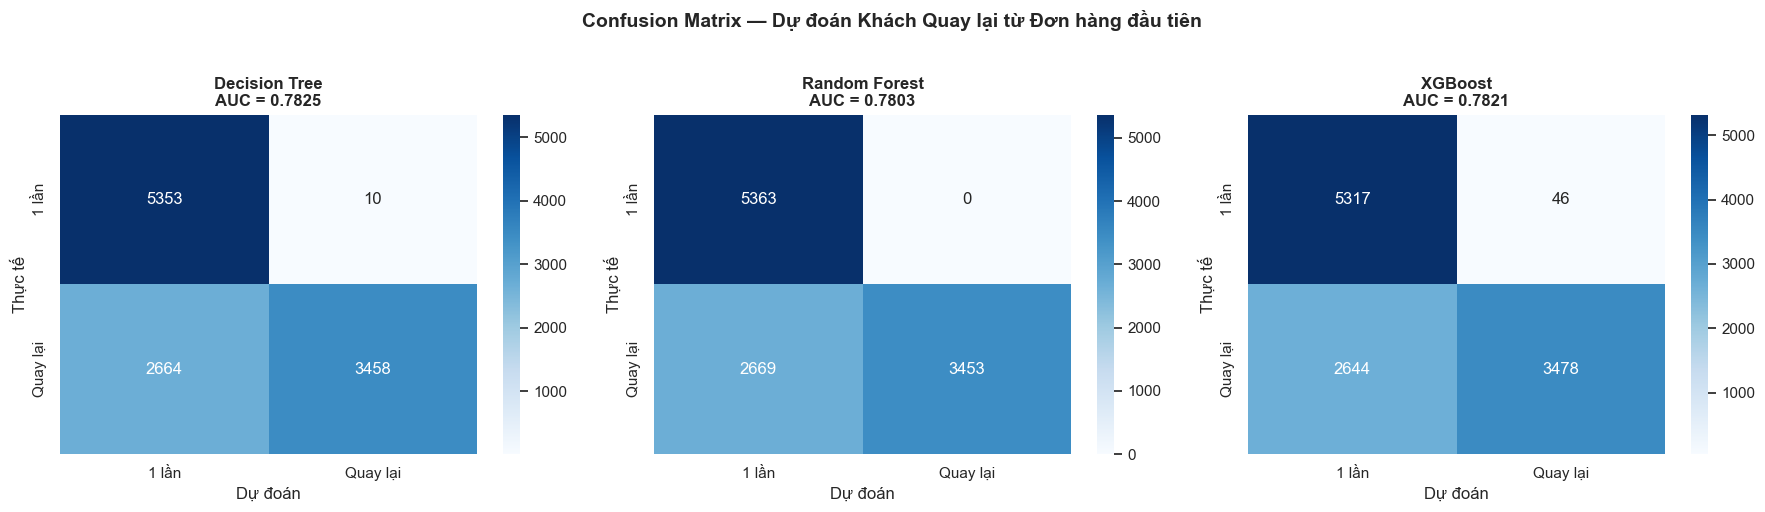

In [16]:
if df is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_test, res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['1 lần', 'Quay lại'],
                    yticklabels=['1 lần', 'Quay lại'])
        ax.set_title(f'{name}\nAUC = {res["auc"]:.4f}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Dự đoán')
        ax.set_ylabel('Thực tế')
    fig.suptitle('Confusion Matrix — Dự đoán Khách Quay lại từ Đơn hàng đầu tiên',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Classification Report

In [17]:
if df is not None:
    for name, res in results.items():
        print(f"\n{'='*60}")
        print(f"📊 {name}")
        print('='*60)
        print(classification_report(y_test, res['y_pred'],
              target_names=['1 lần (0)', 'Quay lại (1)']))


📊 Decision Tree
              precision    recall  f1-score   support

   1 lần (0)       0.67      1.00      0.80      5363
Quay lại (1)       1.00      0.56      0.72      6122

    accuracy                           0.77     11485
   macro avg       0.83      0.78      0.76     11485
weighted avg       0.84      0.77      0.76     11485


📊 Random Forest
              precision    recall  f1-score   support

   1 lần (0)       0.67      1.00      0.80      5363
Quay lại (1)       1.00      0.56      0.72      6122

    accuracy                           0.77     11485
   macro avg       0.83      0.78      0.76     11485
weighted avg       0.84      0.77      0.76     11485


📊 XGBoost
              precision    recall  f1-score   support

   1 lần (0)       0.67      0.99      0.80      5363
Quay lại (1)       0.99      0.57      0.72      6122

    accuracy                           0.77     11485
   macro avg       0.83      0.78      0.76     11485
weighted avg       0.84      

## 6. ROC Curve — So sánh 3 mô hình

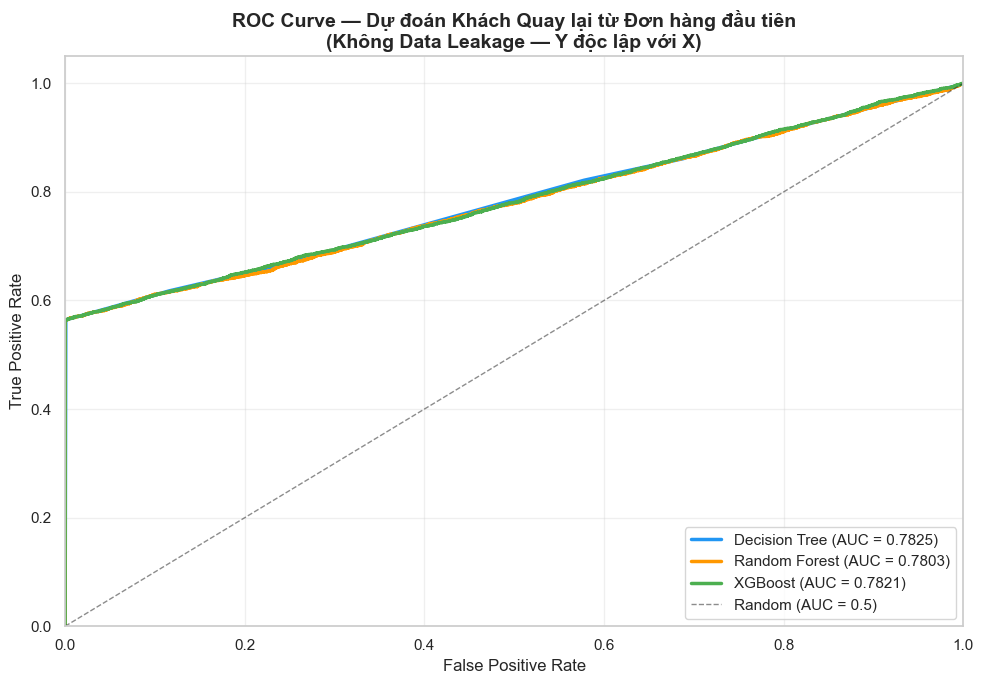

In [18]:
if df is not None:
    plt.figure(figsize=(10, 7))
    colors = ['#2196F3', '#FF9800', '#4CAF50']
    for (name, res), color in zip(results.items(), colors):
        plt.plot(res['fpr'], res['tpr'], color=color, lw=2.5,
                 label=f'{name} (AUC = {res["auc"]:.4f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.5)')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('ROC Curve — Dự đoán Khách Quay lại từ Đơn hàng đầu tiên\n(Không Data Leakage — Y độc lập với X)',
              fontsize=14, fontweight='bold')
    plt.legend(loc='lower right', fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 7. Bảng tổng hợp

In [19]:
if df is not None:
    rows = []
    for name, res in results.items():
        rows.append({
            'Mô hình': name,
            'Accuracy': f"{accuracy_score(y_test, res['y_pred']):.4f}",
            'Precision (Quay lại)': f"{precision_score(y_test, res['y_pred']):.4f}",
            'Recall (Quay lại)': f"{recall_score(y_test, res['y_pred']):.4f}",
            'F1 (Quay lại)': f"{f1_score(y_test, res['y_pred']):.4f}",
            'AUC': f"{res['auc']:.4f}"
        })
    display(pd.DataFrame(rows))

,Mô hình,Accuracy,Precision (Quay lại),Recall (Quay lại),F1 (Quay lại),AUC
0,Decision Tree,0.7672,0.9971,0.5648,0.7212,0.7825
1,Random Forest,0.7676,1.0000,0.5640,0.7213,0.7803
2,XGBoost,0.7658,0.9869,0.5681,0.7211,0.7821


## 8. Feature Importance — Yếu tố nào dự đoán VIP?

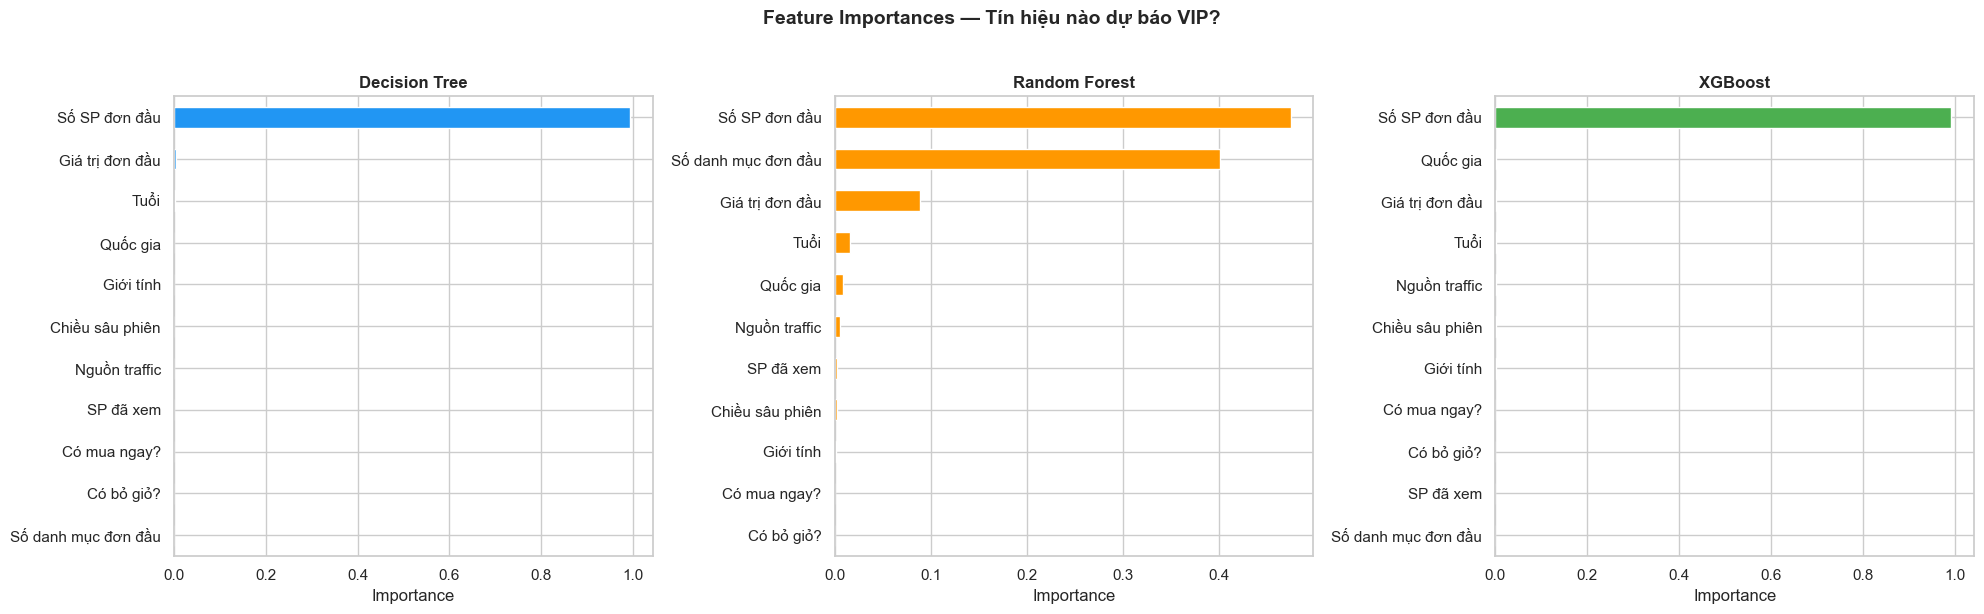

In [20]:
if df is not None:
    nice_names = {
        'first_order_value': 'Giá trị đơn đầu',
        'first_order_num_items': 'Số SP đơn đầu',
        'first_order_num_categories': 'Số danh mục đơn đầu',
        'first_session_depth': 'Chiều sâu phiên',
        'first_session_products_viewed': 'SP đã xem',
        'first_session_carted': 'Có bỏ giỏ?',
        'first_session_purchased': 'Có mua ngay?',
        'age': 'Tuổi',
        'gender_enc': 'Giới tính',
        'country_enc': 'Quốc gia',
        'first_traffic_source_enc': 'Nguồn traffic',
    }

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    colors_fi = ['#2196F3', '#FF9800', '#4CAF50']

    for ax, (name, res), color in zip(axes, results.items(), colors_fi):
        importances = pd.Series(
            res['model'].feature_importances_, index=FEATURE_COLS
        ).sort_values(ascending=True)
        importances.index = [nice_names.get(i, i) for i in importances.index]
        importances.plot(kind='barh', ax=ax, color=color)
        ax.set_title(f'{name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance')

    fig.suptitle('Feature Importances — Tín hiệu nào dự báo VIP?',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 9. Cây Quyết Định — Trực quan hóa

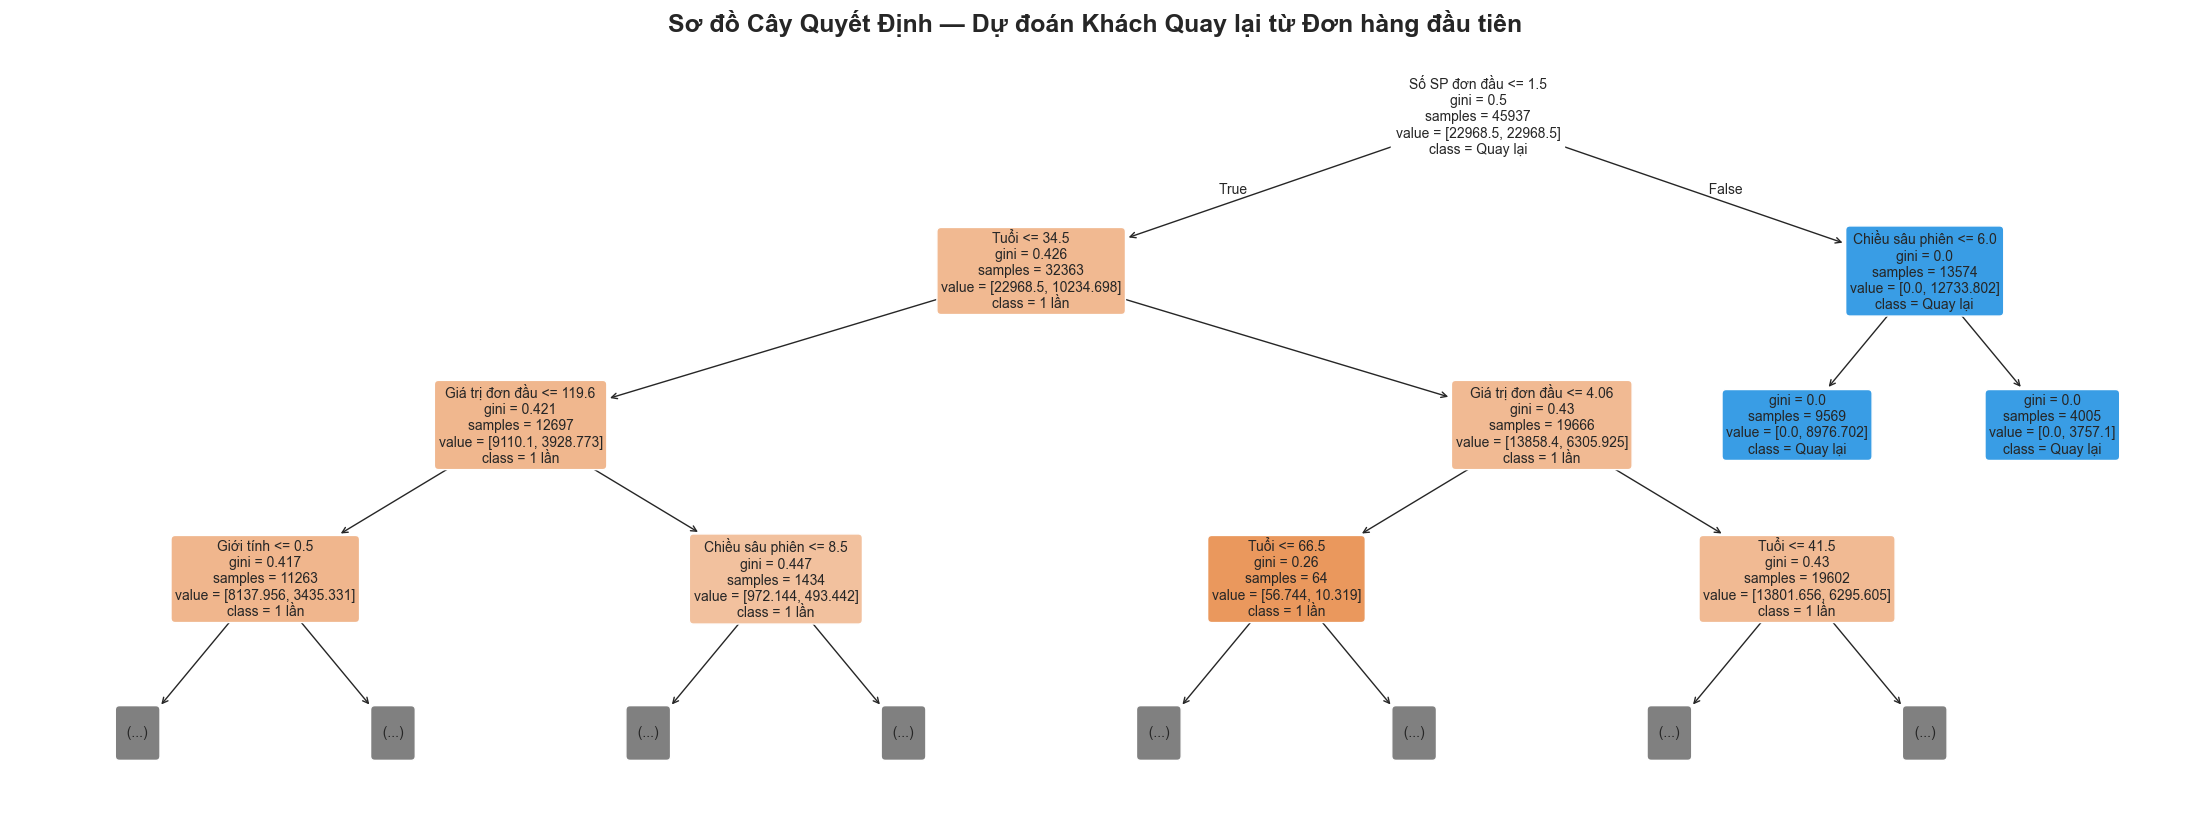

In [21]:
if df is not None:
    plt.figure(figsize=(28, 10))
    feature_names_display = [nice_names.get(f, f) for f in FEATURE_COLS]
    plot_tree(results['Decision Tree']['model'],
              feature_names=feature_names_display,
              class_names=['1 lần', 'Quay lại'],
              filled=True, rounded=True, fontsize=10, max_depth=3)
    plt.title("Sơ đồ Cây Quyết Định — Dự đoán Khách Quay lại từ Đơn hàng đầu tiên",
              fontsize=18, fontweight='bold')
    plt.show()

## 10. Kết luận

In [22]:
if df is not None:
    best_model = max(results, key=lambda x: results[x]['auc'])
    best_auc = results[best_model]['auc']

    print("="*65)
    print("📋 KẾT LUẬN LỚP 2 — DỰ ĐOÁN KHÁCH HÀNG SẼ QUAY LẠI")
    print("="*65)
    print(f"\n🏆 Mô hình tốt nhất: {best_model} (AUC = {best_auc:.4f})")
    print(f"\n📊 FEATURES QUAN TRỌNG NHẤT:")
    best_fi = pd.Series(
        results[best_model]['model'].feature_importances_, index=FEATURE_COLS
    ).sort_values(ascending=False).head(5)
    for feat, imp in best_fi.items():
        print(f"   • {nice_names.get(feat, feat)}: {imp:.4f}")
    print(f"\n💼 Ý NGHĨA KINH DOANH:")
    print("  • Ngay sau đơn hàng đầu tiên, hệ thống dự đoán khả năng khách quay lại")
    print("  • Nếu P(Quay lại) > 60% → Gửi email cảm ơn + ưu đãi đơn thứ 2")
    print("  • Nếu P(Quay lại) < 40% → Chạy remarketing để kéo khách quay lại")

📋 KẾT LUẬN LỚP 2 — DỰ ĐOÁN KHÁCH HÀNG SẼ QUAY LẠI

🏆 Mô hình tốt nhất: Decision Tree (AUC = 0.7825)

📊 FEATURES QUAN TRỌNG NHẤT:
   • Số SP đơn đầu: 0.9935
   • Giá trị đơn đầu: 0.0034
   • Tuổi: 0.0016
   • Quốc gia: 0.0008
   • Giới tính: 0.0003

💼 Ý NGHĨA KINH DOANH:
  • Ngay sau đơn hàng đầu tiên, hệ thống dự đoán khả năng khách quay lại
  • Nếu P(Quay lại) > 60% → Gửi email cảm ơn + ưu đãi đơn thứ 2
  • Nếu P(Quay lại) < 40% → Chạy remarketing để kéo khách quay lại
